<h3> Penjelasan singkat terkait data ini. <br>
a.	customer_id: Nomor identitas unik untuk setiap nasabah. <br>
b.	credit_lines_outstanding: Jumlah fasilitas kredit atau pinjaman aktif yang saat ini dimiliki oleh nasabah (contoh: jumlah kartu kredit atau cicilan lain yang sedang berjalan). <br>
c.	loan_amt_outstanding: Sisa jumlah pokok pinjaman (dalam mata uang tertentu) yang belum dibayarkan oleh nasabah. <br>
d.	total_debt_outstanding: Total keseluruhan utang yang dimiliki nasabah dari berbagai sumber atau fasilitas kredit. <br>
e.	income: Total pendapatan tahunan nasabah. <br>
f.	years_employed: Jumlah tahun lamanya nasabah telah bekerja atau memiliki pekerjaan tetap. Ini sering menjadi indikator stabilitas finansial. <br>
g.	fico_score: Skor FICO (Fair Isaac Corporation), yaitu metrik standar yang mengukur tingkat kelayakan atau reputasi kredit seseorang berdasarkan riwayat finansialnya. Semakin tinggi skornya, semakin baik reputasi kredit nasabah tersebut. <br>
h.	default (Target Variable): Indikator biner yang menunjukkan apakah nasabah tersebut pada akhirnya gagal membayar pinjamannya secara tepat waktu. Angka 1 biasanya berarti nasabah gagal bayar (default), sedangkan 0 berarti nasabah lancar membayar. Fitur ini akan menjadi target/label untuk diprediksi oleh model.

In [2]:
# Ini biar gampang ya narik datanya biar gak usah upload file lagi. Jadi langsung jalanin aja
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/fazqin/Dataset_FinPro/refs/heads/main/credit_loss_data.csv"

df = pd.read_csv(url)
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


## 1. Data Preparation


In [ ]:
sns.set_palette('tab10')

df_eda = df.copy()

In [ ]:
print(f'Missing value:\n{'='*14}\n{df_eda.isnull().sum()}')

Missing value:
customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64


Tidak ada missing value pada data

In [ ]:
print(f'Total of duplicate row: {df_eda.duplicated().sum()}')

Total of duplicate row: 0


Tidak ada data duplikat

In [ ]:
numerical_feature = df_eda.select_dtypes(include=['int64', 'float64']).drop(columns=['customer_id', 'default'])

for feature in numerical_feature:

    q1 = df_eda[feature].quantile(0.25)
    q3 = df_eda[feature].quantile(0.75)
    iqr = q3 - q1


    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    # Check the Outliers
    outliers = df_eda[(df_eda[feature] < lower_bound) | (df_eda[feature] > upper_bound)]
    print(f'[{feature}] total outliers: {len(outliers)}')
    print(f'[{feature}] total outliers (percentage): {(len(outliers)/df_eda.shape[0]) * 100:.2f}%\n')

[credit_lines_outstanding] total outliers: 0
[credit_lines_outstanding] total outliers (percentage): 0.00%

[loan_amt_outstanding] total outliers: 115
[loan_amt_outstanding] total outliers (percentage): 1.15%

[total_debt_outstanding] total outliers: 602
[total_debt_outstanding] total outliers (percentage): 6.02%

[income] total outliers: 86
[income] total outliers (percentage): 0.86%

[years_employed] total outliers: 0
[years_employed] total outliers (percentage): 0.00%

[fico_score] total outliers: 72
[fico_score] total outliers (percentage): 0.72%



* loan_amt_outstanding: relatif kecil
* total_debt_outstanding: cukup signifikan
* income: relatif kecil
* fico_score: relatif kecil

In [ ]:
print(f'[loan_amt_outstanding] mean: {df_eda['loan_amt_outstanding'].mean()}', '\n')
print(f'[total_debt_outstanding] mean: {df_eda['total_debt_outstanding'].mean()}', '\n')
print(f'[income] mean: {df_eda['income'].mean()}', '\n')
print(f'[fico_score] mean: {df_eda['fico_score'].mean()}', '\n')

outliers[['loan_amt_outstanding', 'total_debt_outstanding', 'income', 'fico_score']].head(10)

[loan_amt_outstanding] mean: 4159.677034265904 

[total_debt_outstanding] mean: 8718.916796726344 

[income] mean: 70039.90140134419 

[fico_score] mean: 637.5577 



,loan_amt_outstanding,total_debt_outstanding,income,fico_score
9,5396.366774,5298.824524,92349.55399,447
347,1398.610404,2649.708007,21976.97259,808
369,4424.819601,20384.267670,73983.50212,466
546,4283.135082,2308.761156,64800.64789,814
703,4803.995367,12920.809080,82500.95110,828
705,5328.582196,20056.749580,91016.20181,455
1017,6448.498229,27370.156270,92152.55180,468
1386,3754.791505,7331.581313,75528.51306,816
1558,3273.847210,20551.525640,70074.28481,440
1593,2845.002894,6870.954791,62328.25136,826


## 2. EDA

### A. Univariate analysis

Karena target kita adalah gagal bayar (0 = lancar, 1 = gagal), kita perlu melihat
apakah proporsi datanya seimbang atau jomplang (imbalanced).

Proporsi Target Variable (Default):
default
0    81.49
1    18.51
Name: proportion, dtype: float64
default
0    8149
1    1851
Name: count, dtype: int64


/tmp/ipykernel_3156/4018220628.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='default', palette='Set2')


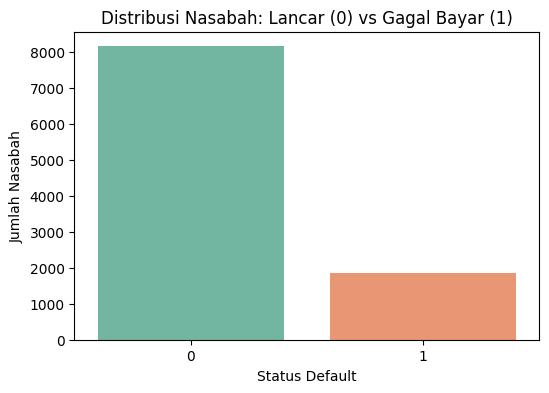

In [ ]:
print("Proporsi Target Variable (Default):")
print(df['default'].value_counts(normalize=True) * 100)

print(df['default'].value_counts())

# Visualisasi dengan Bar Chart
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='default', palette='Set2')
plt.title('Distribusi Nasabah: Lancar (0) vs Gagal Bayar (1)')
plt.xlabel('Status Default')
plt.ylabel('Jumlah Nasabah')
plt.show()

Default adalah rare event, sehingga analisis dan modeling harus memperhatikan ketidakseimbangan kelas agar tidak menghasilkan model yang bias terhadap kelas mayoritas.

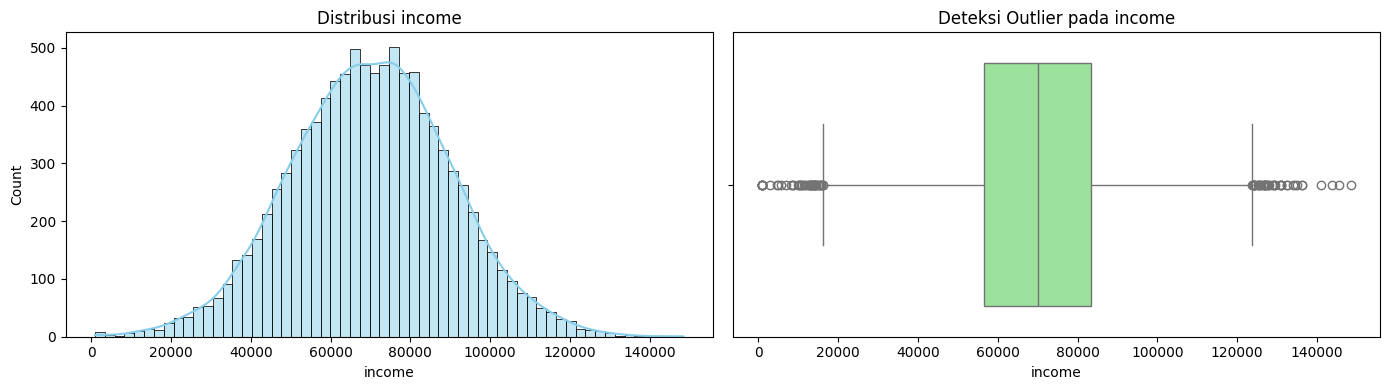

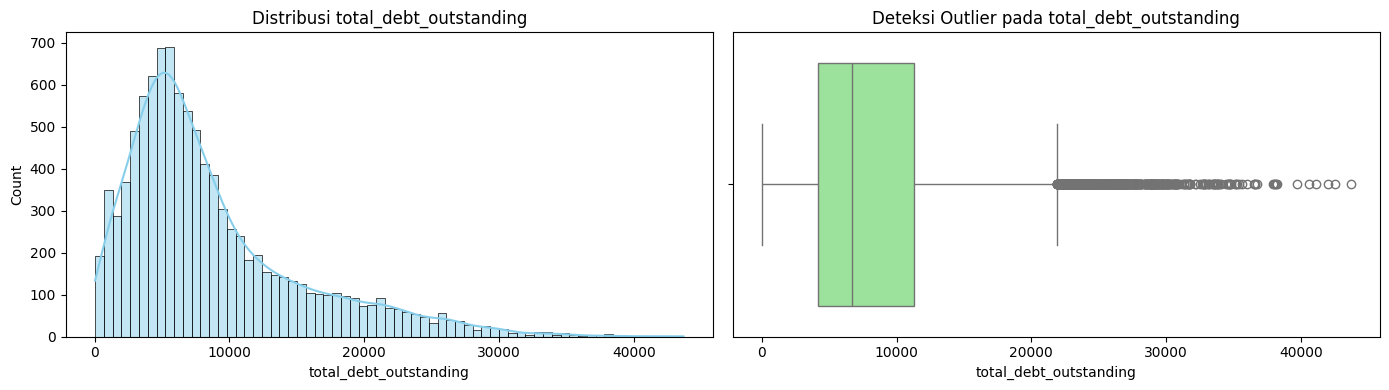

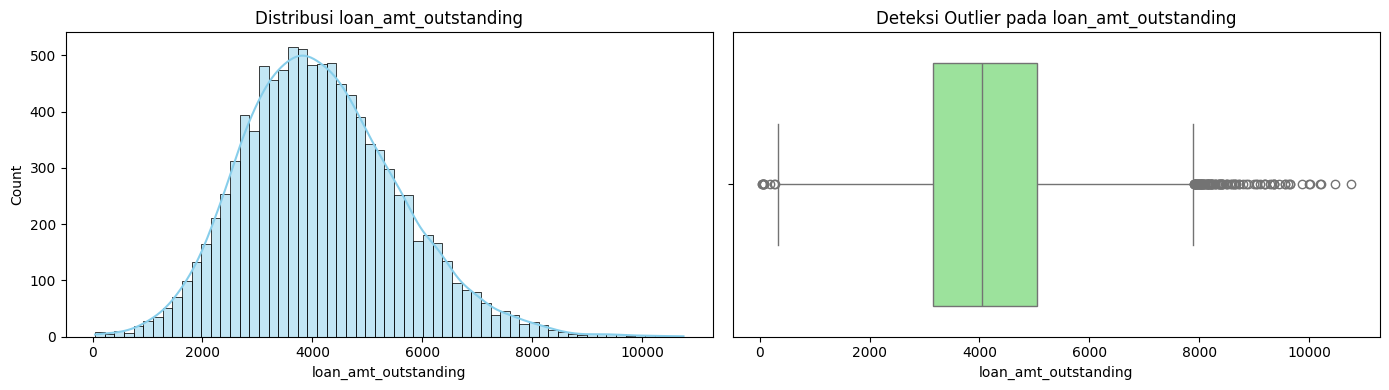

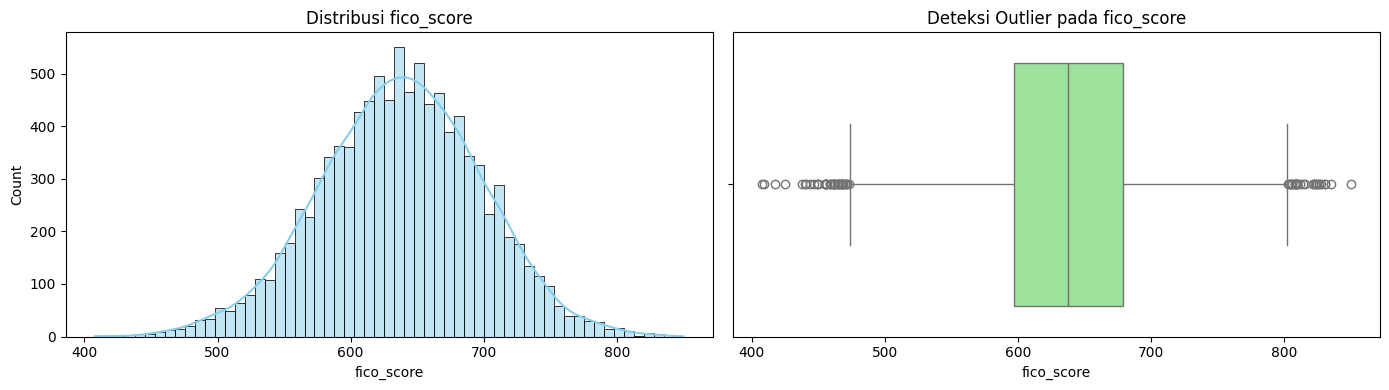

In [3]:
# Daftar kolom numerik yang ingin dianalisis
numerical_cols = ['income', 'total_debt_outstanding', 'loan_amt_outstanding', 'fico_score']

for col in numerical_cols:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    # Grafik 1: Histogram (Melihat bentuk distribusi)
    sns.histplot(df[col], kde=True, ax=ax[0], color='skyblue')
    ax[0].set_title(f'Distribusi {col}')

    # Grafik 2: Boxplot (Mendeteksi nilai ekstrem/outliers)
    sns.boxplot(x=df[col], ax=ax[1], color='lightgreen')
    ax[1].set_title(f'Deteksi Outlier pada {col}')

    plt.tight_layout()
    plt.show()

* income: sebagian kecil nasabah memiliki income sangat tinggi dan mayoritas berada di rentang menengah
* total_debt_outstanding: beberapa nasabah memiliki utang yang sangat tinggi
* loan_amt_outstanding: mayoritas nasabah memiliki sisa pinjaman dalam jumlah relatif kecil
* fico_score: distribusi relatif normal, terpusat di nilai tengah, variabel lebih stabil dibanding yang lain

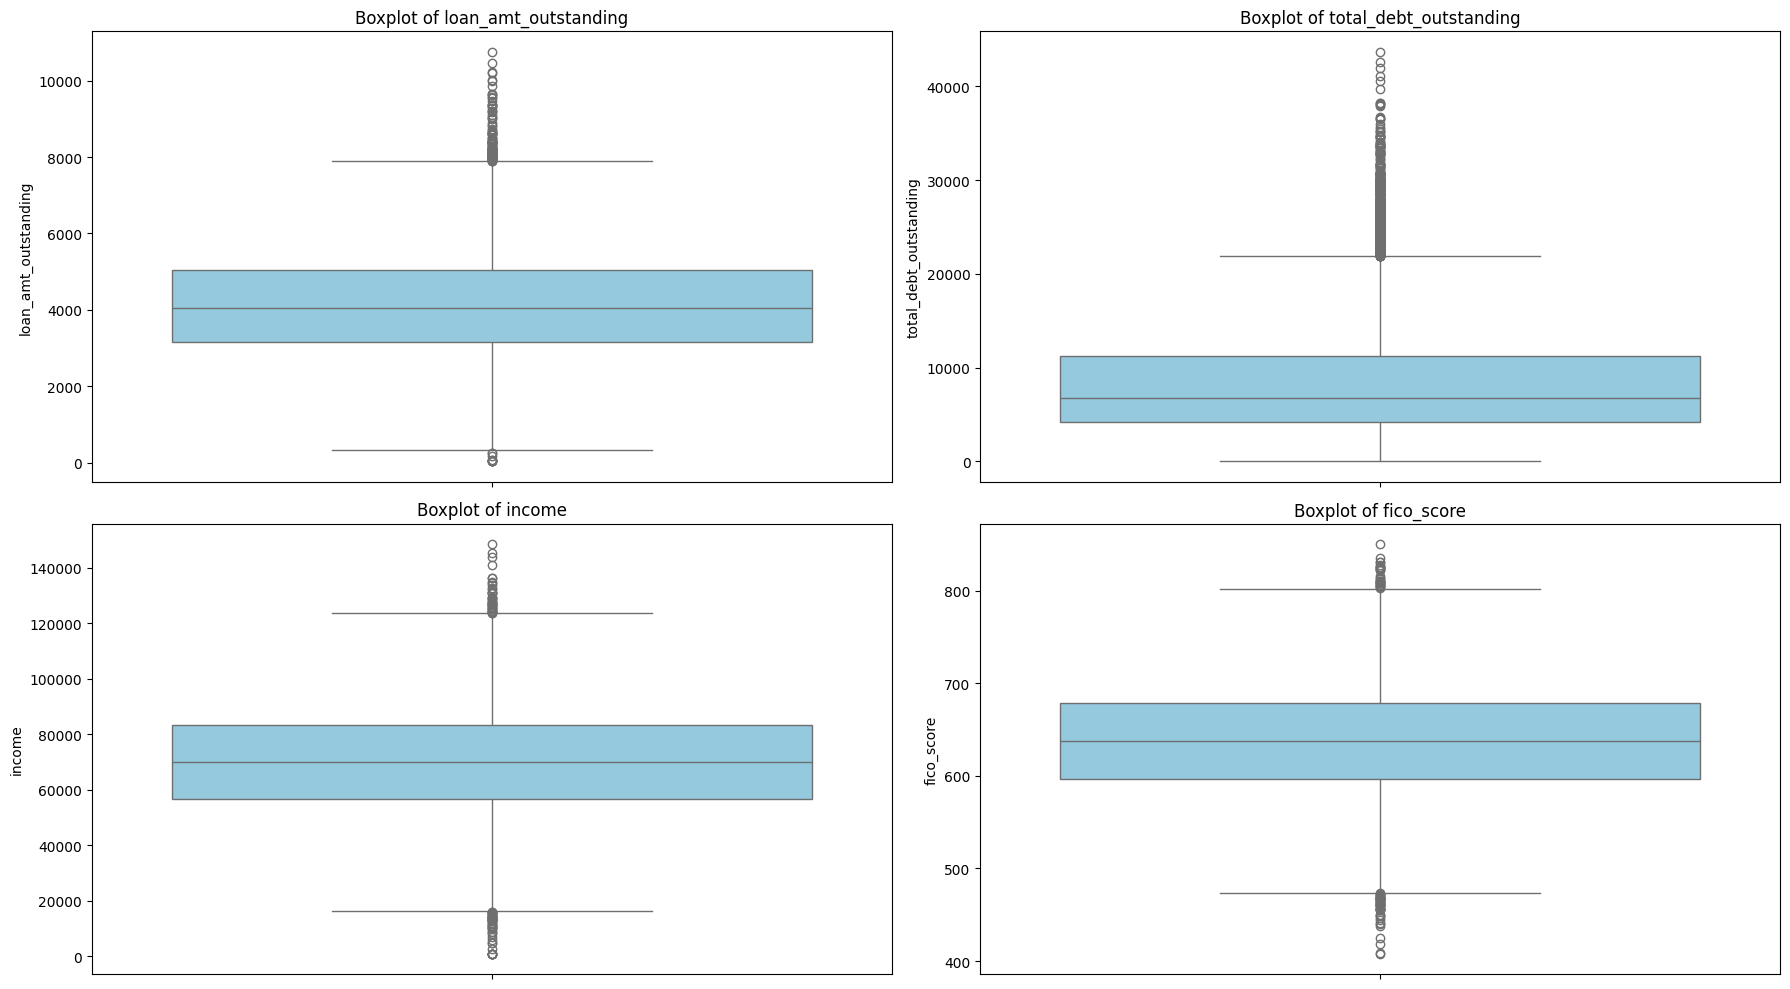

In [ ]:
features = ['loan_amt_outstanding', 'total_debt_outstanding', 'income', 'fico_score']

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

### B. Bivariate Analysis

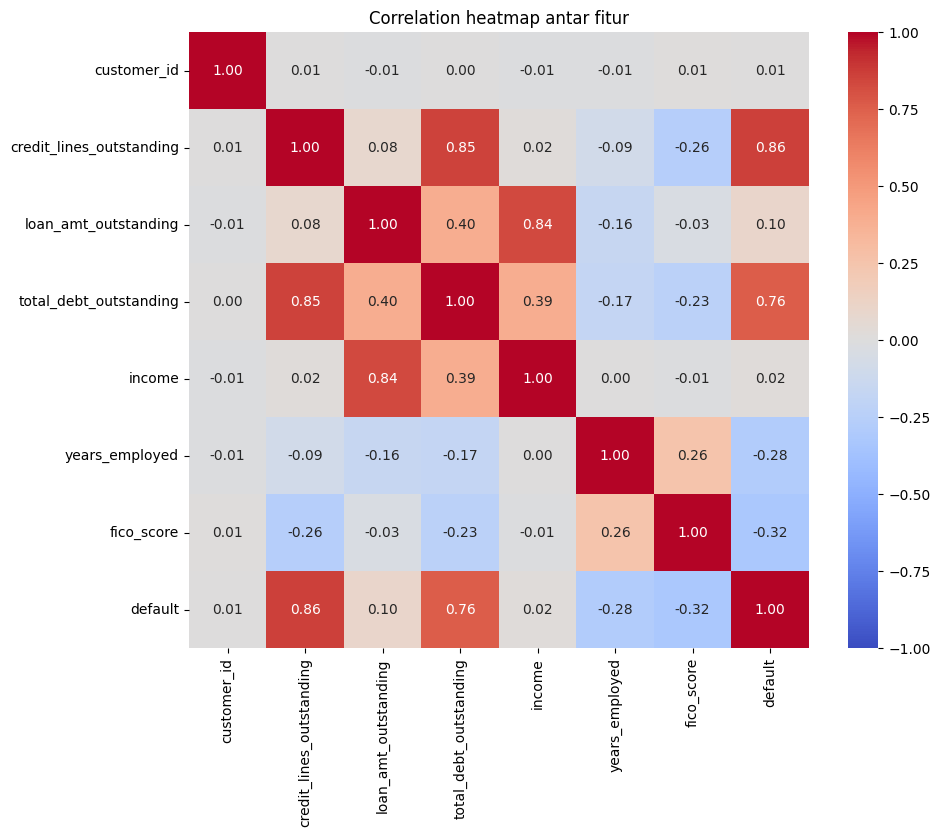

In [ ]:
plt.figure(figsize=(10, 8))
correlation = df_eda.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap antar fitur')
plt.show()

* fico_score & default: semakin tinggi skor kredit, semakin kecil kemungkinan gagal bayar
* credit_utilization & default: semakin tinggi penggunaan kredit, semakin besar risiko gagal bayar
* loan_amt_outstanding: jumlah pinjaman saja tidak cukup menjelaskan default

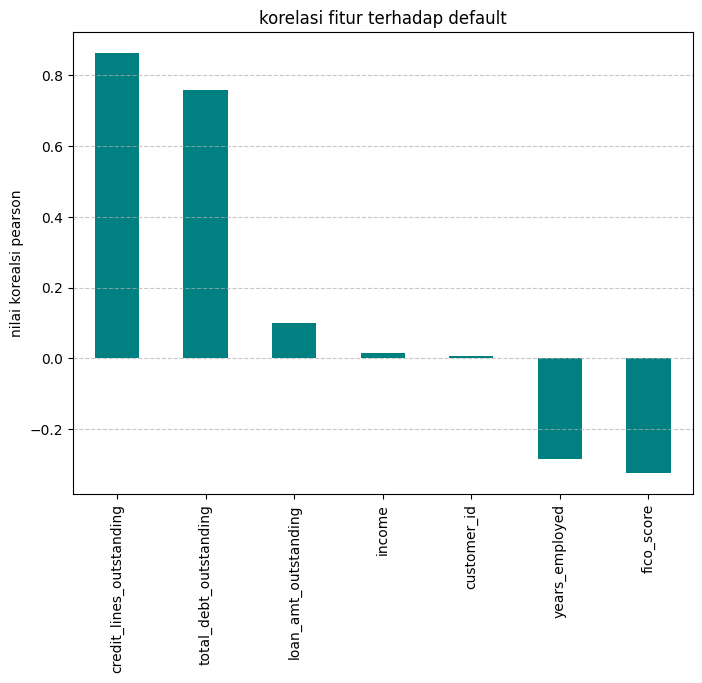

In [ ]:
correlation = df_eda.corr(numeric_only=True)

correlation['default'].sort_values(ascending=False).drop('default').plot(kind='bar', figsize=(8, 6), color='teal')
plt.title('korelasi fitur terhadap default', fontsize=12)
plt.ylabel('nilai korealsi pearson')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**FAKTOR KORELASI POSITIF**:
Berdasarkan analisis korelasi, korelasi positif tertinggi adalah credit_lines_outstanding dan total_debt_outstanding. Semakin banyak kredit yang dimiliki dan semakin besar total utang, maka kecenderungan untuk mengalami default meningkat.


---

**FAKTOR KORELASI NEGATIF**:
Berdasarkan fico_score dan years_employed, semakin tinggi skor kredit dan semakin lama masa kerja, maka risiko default cenderung menurun. Stabilitas finansial dan riwayat kredit berperan dalam menurunkan risiko gagal bayar.

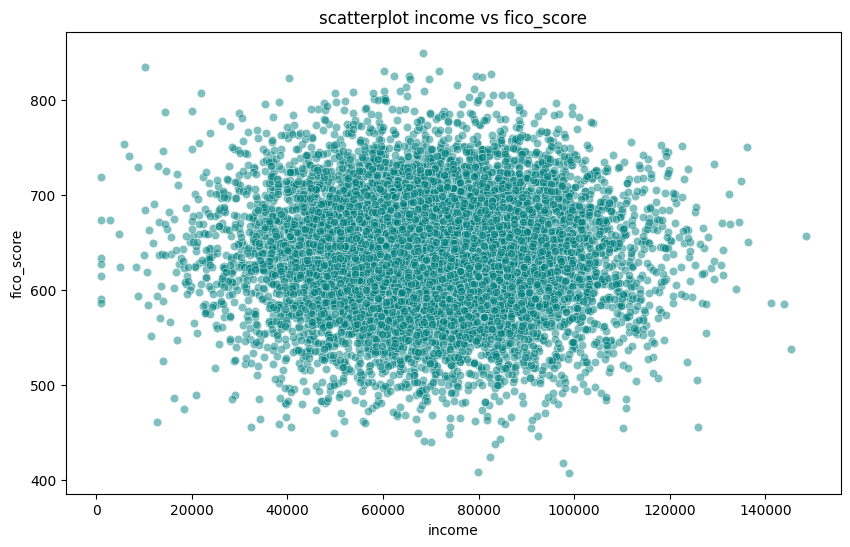

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='income', y='fico_score', alpha=0.5, color='teal')
plt.title('scatterplot income vs fico_score')
plt.xlabel('income')
plt.ylabel('fico_score')
plt.show()

Tidak terlihat pola naik atau turun yang konsisten, sebaran sangat lebar di smeua rentang income. Tidak terdapat hubungan linear yang kiat antara income dan fico_score.

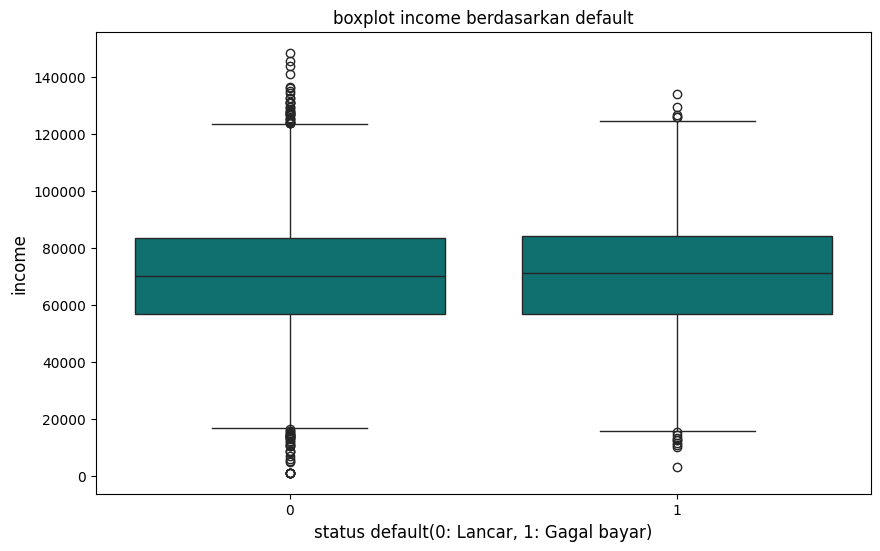

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='default', y='income', color='teal')
plt.title('boxplot income berdasarkan default')
plt.xlabel('status default(0: Lancar, 1: Gagal bayar)', fontsize=12)
plt.ylabel('income', fontsize=12)
plt.show()

Median income antara Non-default dan Default terlihat hampir sama dan banyak outlier di kedua kelompok. Income tidak membedakan secara jelas anttara nasabah yang default dan tidak.

/tmp/ipykernel_8288/33569312.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='credit_lines_outstanding', data=df, palette='viridis')


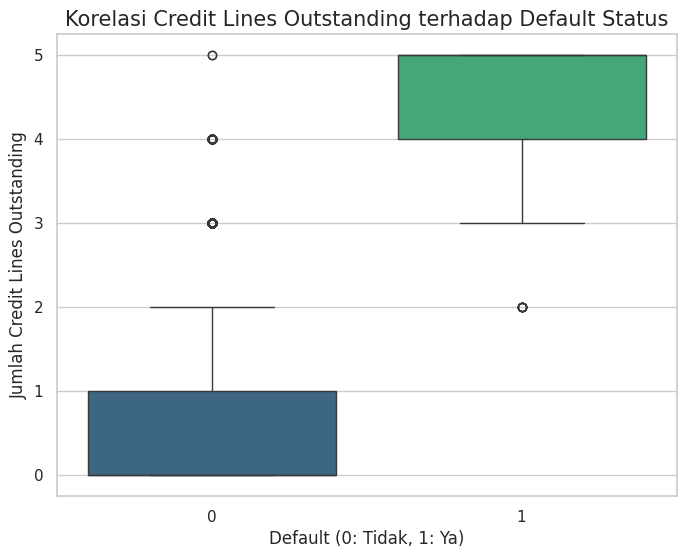

In [ ]:
sns.set(style="whitegrid")

# Korelasi Credit Lines Outstanding terhadap Default
plt.figure(figsize=(8, 6))
sns.boxplot(x='default', y='credit_lines_outstanding', data=df, palette='viridis')
plt.title('Korelasi Credit Lines Outstanding terhadap Default Status', fontsize=15)
plt.xlabel('Default (0: Tidak, 1: Ya)', fontsize=12)
plt.ylabel('Jumlah Credit Lines Outstanding', fontsize=12)
plt.show()

### Default=1 lebih tinggi menandakan nasabah cenderung gagal bayar ketika nasabah terlalu sibuk membayar tanggungan cicilan kredit yang banyak.

/tmp/ipykernel_8288/2565931017.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='total_debt_outstanding', data=df, palette='coolwarm')


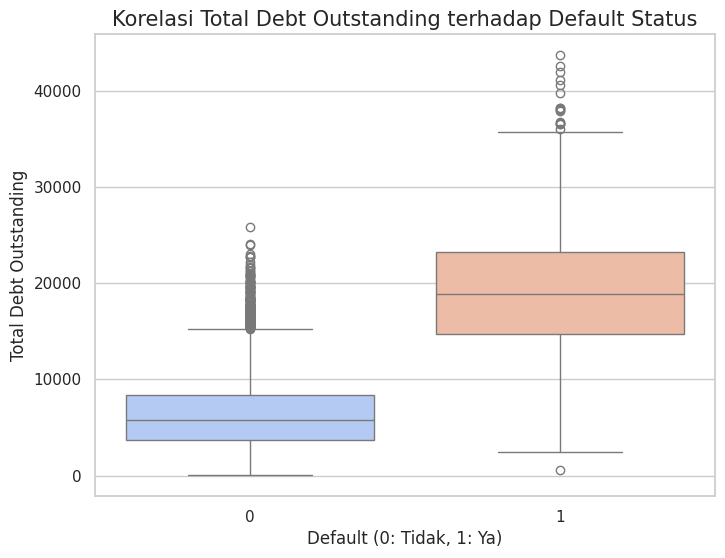

In [ ]:
# Korelasi Total Debt Outstanding terhadap Default
plt.figure(figsize=(8, 6))
sns.boxplot(x='default', y='total_debt_outstanding', data=df, palette='coolwarm')
plt.title('Korelasi Total Debt Outstanding terhadap Default Status', fontsize=15)
plt.xlabel('Default (0: Tidak, 1: Ya)', fontsize=12)
plt.ylabel('Total Debt Outstanding', fontsize=12)
plt.show()

####sangat jelas bahwa jika nasabah memiliki total utang lebih banyak cenderung gagal bayar. Ini menunjukkan bahwa beban utang yang terlalu besar adalah faktor risiko utama.

## 3. Feature Engineering

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

In [ ]:
df_prep = df.copy()
df_prep = df.copy().drop(columns=['customer_id'])

#feature engineered
df_prep['debt_to_income_ratio'] = df_prep['total_debt_outstanding'] / (df_prep['income'] + 1e-9)
df_prep['loan_to_income_ratio'] = df_prep['loan_amt_outstanding'] / (df_prep['income'] + 1e-9)

In [ ]:
#Fico Score
bins_fico = [0, 579, 669, 739, 799, 850]
labels_fico = ['Poor', 'Fair', 'Good', 'Very_Good', 'Exceptional']
df_prep['fico_category'] = pd.cut(df_prep['fico_score'], bins=bins_fico, labels=labels_fico)
df_prep = df_prep.drop(columns=['fico_score'])

In [ ]:
# Now, drop the desired columns for this specific run
df_prep = df_prep.drop(columns=['debt_to_income_ratio', 'credit_lines_outstanding', 'total_debt_outstanding'])

Di perbankan, variabel ini sering kali korelasinya kuat karena sistem baru mencatat total utang yang membengkak setelah nasabah mulai kesulitan bayar. dan mereka mengandung "informasi dari masa depan" yang merusak validitas prediksi model

In [ ]:
# perform the data split again
X = df_prep.drop('default', axis=1)
y = df_prep['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
#Handling outlier berdasarkan kolom yang tersisa
cols_to_cap = ['income', 'loan_amt_outstanding', 'years_employed', 'loan_to_income_ratio']

for col in cols_to_cap:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - (1.5 * IQR), Q3 + (1.5 * IQR)

    X_train[col] = np.clip(X_train[col], lower, upper)
    X_test[col] = np.clip(X_test[col], lower, upper)

In [ ]:
#One-Hot Encoding untuk fico_category
X_train = pd.get_dummies(X_train, columns=['fico_category'], drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=['fico_category'], drop_first=True, dtype=int)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import pandas as pd # Ensure pandas is imported for get_dummies

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Menggunakan class_weight='balanced' untuk menangani data yang tidak seimbang
model_baru = LogisticRegression(random_state=42, class_weight='balanced')

# Train Model
model_baru.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

Yang **direvisi** train split datanya jadi sebelum handling outlier dan di nambahin drop di df_prep untuk variable yang kira2 merusak

## 4. Data Modeling


Cross-validation Scores for all models:
[Logistic Regression] Hasil 5X ujian (CV Scores): [0.7225   0.7075   0.693125 0.675    0.714375]
[Logistic Regression] Rata-rata akurasi CV: 70.25%

[XGBoost] Hasil 5X ujian (CV Scores): [0.813125 0.8125   0.8175   0.814375 0.814375]
[XGBoost] Rata-rata akurasi CV: 81.44%

[adaBoost] Hasil 5X ujian (CV Scores): [0.825    0.82875  0.824375 0.83125  0.82625 ]
[adaBoost] Rata-rata akurasi CV: 82.71%

[Gradient Boosting] Hasil 5X ujian (CV Scores): [0.82875  0.829375 0.82875  0.8325   0.825   ]
[Gradient Boosting] Rata-rata akurasi CV: 82.89%

[Random Forest] Hasil 5X ujian (CV Scores): [0.733125 0.7275   0.69875  0.6775   0.7175  ]
[Random Forest] Rata-rata akurasi CV: 71.09%



/tmp/ipykernel_8288/3955326103.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Average Accuracy', y='Model', data=df_model_accuracy, palette='viridis')


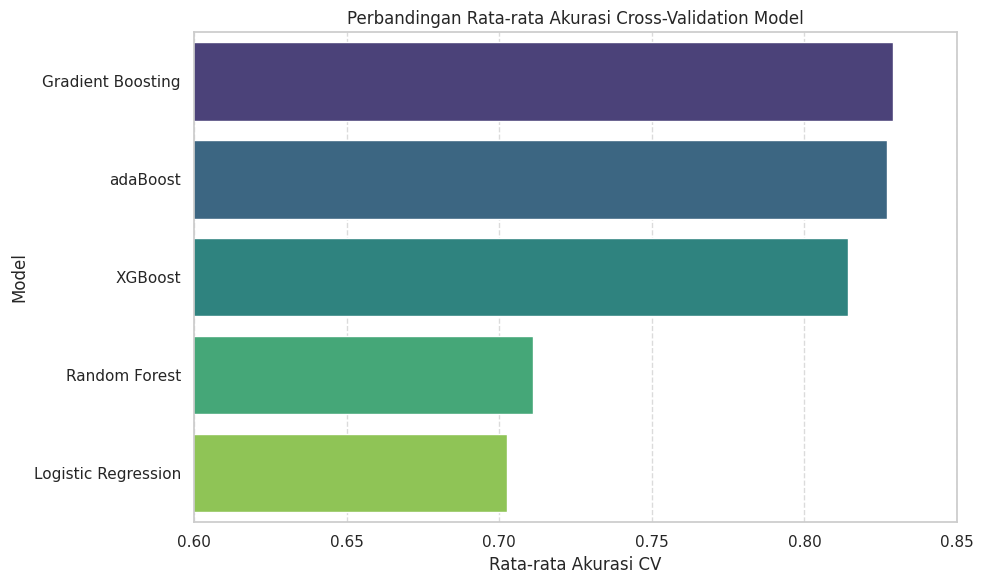

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=10, min_samples_leaf=42, random_state=42, class_weight='balanced')

models2 = {
    "Logistic Regression": LogisticRegression(random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "adaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting" : GradientBoostingClassifier(random_state=42),
    "Random Forest": rf_model
}

print("Cross-validation Scores for all models:")
print("="*40)

for name, model in models2.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"[{name}] Hasil 5X ujian (CV Scores): {cv_scores}")
    print(f"[{name}] Rata-rata akurasi CV: {cv_scores.mean() * 100:.2f}%\n")

# Train the Random Forest model separately as it was already defined
rf_model.fit(X_train, y_train)

model_accuracy_data = {
    "Model": ["Logistic Regression", "XGBoost", "adaBoost", "Gradient Boosting", "Random Forest"],
    "Average Accuracy": [0.7025, 0.8144, 0.8271, 0.8289, 0.7109]
}

df_model_accuracy = pd.DataFrame(model_accuracy_data)

# Urutkan berdasarkan akurasi untuk visualisasi yang lebih baik
df_model_accuracy = df_model_accuracy.sort_values(by='Average Accuracy', ascending=False)

# Buat bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Average Accuracy', y='Model', data=df_model_accuracy, palette='viridis')
plt.title('Perbandingan Rata-rata Akurasi Cross-Validation Model')
plt.xlabel('Rata-rata Akurasi CV')
plt.ylabel('Model')
plt.xlim(0.6, 0.85)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 5. Model Evaluation

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Get the Gradient Boosting model
gradient_boosting_model = models2["Gradient Boosting"]

# Train the model if it hasn't been trained already (important for consistent evaluation)
# This step might be redundant if the model was already trained in the cross-validation loop
# For safety, we can fit it again here.
gradient_boosting_model.fit(X_train, y_train)

# Predictions on training data
y_train_pred_gb = gradient_boosting_model.predict(X_train)

# Predictions on test data
y_test_pred_gb = gradient_boosting_model.predict(X_test)

print("\n--- Gradient Boosting Model Performance ---")

print("\nClassification Report (Training Data):")
print(classification_report(y_train, y_train_pred_gb))
train_accuracy = accuracy_score(y_train, y_train_pred_gb)
print(f"Accuracy on Training Data: {train_accuracy:.4f}")

print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_pred_gb))
test_accuracy = accuracy_score(y_test, y_test_pred_gb)
print(f"Accuracy on Test Data: {test_accuracy:.4f}")

print("\n" + "="*20)
print("cek overfitting")
print(f"Selisih Akurasi (Training - Test): {(train_accuracy - test_accuracy):.4f}")
print("="*20)


--- Gradient Boosting Model Performance ---

Classification Report (Training Data):
              precision    recall  f1-score   support

           0       0.85      0.97      0.91      6519
           1       0.68      0.25      0.36      1481

    accuracy                           0.84      8000
   macro avg       0.76      0.61      0.64      8000
weighted avg       0.82      0.84      0.81      8000

Accuracy on Training Data: 0.8390

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.84      0.97      0.90      1630
           1       0.56      0.19      0.29       370

    accuracy                           0.82      2000
   macro avg       0.70      0.58      0.59      2000
weighted avg       0.79      0.82      0.79      2000

Accuracy on Test Data: 0.8225

cek overfitting
Selisih Akurasi (Training - Test): 0.0165



 === CLASSIFICATION REPORT (DATA TEST) === 
                 precision    recall  f1-score   support

Mampu Bayar (0)       0.84      0.97      0.90      1630
Gagal Bayar (1)       0.56      0.19      0.29       370

       accuracy                           0.82      2000
      macro avg       0.70      0.58      0.59      2000
   weighted avg       0.79      0.82      0.79      2000



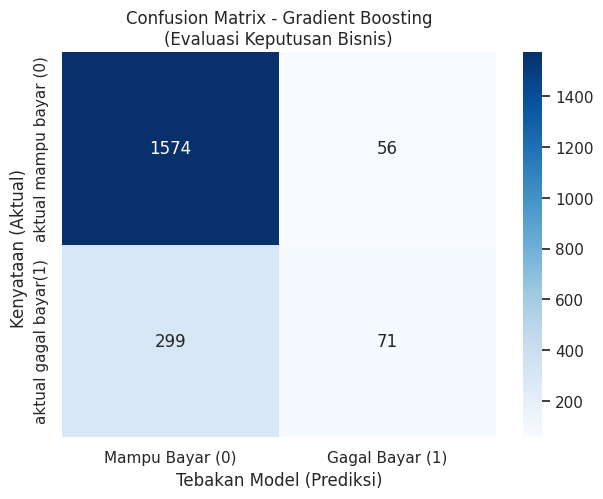

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Classification report nampilin Precision, Recall, dan F1-Score lengkap buat kelas 0 dan 1
print("\n === CLASSIFICATION REPORT (DATA TEST) === ")
print(classification_report(y_test, y_test_pred_gb, target_names=['Mampu Bayar (0)', 'Gagal Bayar (1)']))

# Bikin Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_gb)
plt.figure(figsize=(7,5))
# Pake heatmap biar warnanya enak dilihat
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Mampu Bayar (0)', 'Gagal Bayar (1)'],
            yticklabels=['aktual mampu bayar (0)', 'aktual gagal bayar(1)'])
plt.title('Confusion Matrix - Gradient Boosting\n(Evaluasi Keputusan Bisnis)')
plt.ylabel('Kenyataan (Aktual) ')
plt.xlabel('Tebakan Model (Prediksi)')
plt.show()